# Kinetics of a carrier
This notebook builds a kinetic model of a **symmetric, four-state carrier** - a  model for facilitated-diffusion transporters, which move a solute across a membrane by alternating between an outward-facing and an inward-facing conformation.

It's based on the model and figures from [Bosdriesz et al. 2018](https://doi.org/10.1038/s41598-018-23528-7).

The goal is to reproduce the qualitative result that **a transporter's optimal affinity depends on the external and internal substrate concentrations** &mdash; higher affinity is not always better &mdash; and to understand how and why this differs from plain Michaelis-Menten kinetics. We first explore this with a small toy carrier model, then reproduce it in a realistic yeast glycolysis model.

## The carrier model

The carrier shuttles a solute from an external concentration $S_e$ to an internal concentration $S_i$ (or vice versa). Its steady-state rate law is:

$$v = e_t \cdot \frac{\dfrac{k_{cat}}{K_M}(S_e - S_i)}{1 + \dfrac{S_e}{K_M} + \dfrac{S_i}{K_M} + \alpha\dfrac{S_e S_i}{K_M^2}}$$

with

$$k_{cat} = \frac{k_2 k_4}{k_2 + k_4} \qquad\qquad \alpha = \frac{4 k_2 k_4}{(k_2+k_4)^2}$$

where $k_2$ and $k_4$ are the translocation rates of the loaded and unloaded carrier, respectively, and $e_t$ is the total amount of carrier. Two things worth noting about $\alpha$:

- It's bounded between 0 and 1, and reaches its maximum of 1 exactly when $k_2 = k_4$ &mdash; the carrier is then maximally "coupled" between the two sides.
- It vanishes when $k_2 \gg k_4$ or $k_4 \gg k_2$. 

We model this as a single reaction $S_e \rightarrow S_i$, holding $S_e$ and $S_i$ fixed (representing a constant external supply) so we can control it directly as an experimental parameter.

In [1]:
import sys
if '../..' not in sys.path:
    sys.path.append('../..')

from basico import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Bulding the carrier model

In [2]:
new_model(name='Carrier model')
add_reaction('R1', 'Se -> Si')

set_species('Si', status='fixed', initial_concentration=1)
set_species('Se', status='fixed');

We define $e_t$, $k_2$, $k_4$, and $K_M$ as free parameters, and derive $k_{cat}$ and $\alpha$ from them via assignment rules, so they stay consistent if $k_2$ or $k_4$ change.

In [3]:
et = 1
k2 = 1
k4 = 8
Km = 1

add_parameter('et', initial_value=et)
add_parameter('k2', initial_value=k2)
add_parameter('k4', initial_value=k4)
add_parameter('Km', initial_value=Km)

# some parameters depend on others - this is set via assignment
add_parameter('kcat', 
              expression='Values[k2] * Values[k4] / (Values[k2] + Values[k4])', 
              status='assignment')
add_parameter('alpha', 
              expression='4 * Values[k2] * Values[k4] / (Values[k2] + Values[k4])^2', 
              status='assignment');
get_parameters()


,type,unit,initial_value,initial_expression,expression,value,rate,key,sbml_id,display_name
name,,,,,,,,,,
et,fixed,,1.000000,,,NaN,0.0,ModelValue_0,,Values[et]
k2,fixed,,1.000000,,,NaN,0.0,ModelValue_1,,Values[k2]
k4,fixed,,8.000000,,,NaN,0.0,ModelValue_2,,Values[k4]
Km,fixed,,1.000000,,,NaN,0.0,ModelValue_3,,Values[Km]
kcat,assignment,,0.888889,,Values[k2] * Values[k4] / ( Values[k2] + Value...,NaN,NaN,ModelValue_4,,Values[kcat]
alpha,assignment,,0.395062,,4 * Values[k2] * Values[k4] / ( Values[k2] + V...,NaN,NaN,ModelValue_5,,Values[alpha]


### Defining the custom rate law


We define a custom rate law based on the publication and map the parameters

In [4]:
add_function('Transporter kinetics',
            'et * (kcat / Km * (Se - Si)) / (1 + Se / Km + Si / Km + alpha * Se * Si / Km^2)',
             mapping = {'Se': 'substrate',
                        'Si': 'product',
                        'Km': 'parameter',
                        'alpha': 'parameter',
                        'kcat': 'parameter'});


In [5]:
set_reaction('R1', function='Transporter kinetics')
set_reaction_parameters('(R1).et', mapped_to='et')
set_reaction_parameters('(R1).kcat', mapped_to='kcat')
set_reaction_parameters('(R1).Km', mapped_to='Km')
set_reaction_parameters('(R1).alpha', mapped_to='alpha')

get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(R1).et,1.000000,R1,global,et
(R1).kcat,0.888889,R1,global,kcat
(R1).Km,1.000000,R1,global,Km
(R1).alpha,0.395062,R1,global,alpha


### Flux vs. $K_M$, for several values of $S_e$

In [6]:
se_values = [2, 10, 100]
km_values =  np.logspace(-1, 3, 20)

rows = []
for se in se_values:
    set_species('Se', initial_concentration = se);
    for km in km_values:
        set_parameters('Km', initial_value=km)

        # this simply evaluates the rate law at the fixed concentrations
        status = run_steadystate()
        fluxes = get_reactions()['flux']
        rows.append({'Se': se, 'Km': km, 'flux': fluxes.R1})


set_parameters('Km', initial_value=Km)  # restore original value
flux_data = pd.DataFrame(rows)

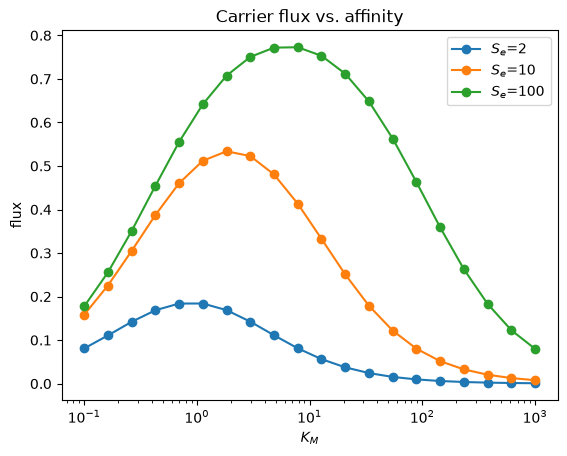

In [7]:
fig, ax = plt.subplots()
for se, g in flux_data.groupby('Se'):
    ax.plot(g['Km'], g['flux'], 'o-', label=f'$S_e$={se}')

ax.set_xscale('log')
ax.set_xlabel('$K_M$')
ax.set_ylabel('flux')
ax.set_title('Carrier flux vs. affinity')
ax.legend()

### Comparison with reversible Michaelis menten kinetics

We add a second reaction, `R2`, to the **same model** &mdash; it can share `Se` and `Si` directly, since both are fixed and neither reaction's flux affects the other. `R2` uses the built-in reversible Michaelis-Menten rate law:


- $K_{ms} = K_{mp} = K_M$ (same affinity as the carrier)
- $V_f = V_r = e_t \cdot k_2$ &mdash; using the **plain** $k_2$, not the carrier's combined $k_{cat} = \frac{k_2k_4}{k_2+k_4}$. This is deliberate: ordinary Michaelis-Menten kinetics has no $k_4$.

In [8]:
add_reaction('R2', 'Se -> Si')
set_species('Si', status='fixed', initial_concentration=1)
set_species('Se', status='fixed');

set_reaction('R2', function='Reversible Michaelis-Menten')

In [9]:
add_parameter('V', 
              expression='Values[et] * Values[k2]', 
              status='assignment');

In [10]:
set_reaction_parameters('(R2).Kms', mapped_to='Km')
set_reaction_parameters('(R2).Kmp', mapped_to='Km')
set_reaction_parameters('(R2).Vf', mapped_to='V')
set_reaction_parameters('(R2).Vr', mapped_to='V')

In [11]:
se_values = [2, 10, 100]
km_values =  np.logspace(-1, 3, 20)

rows = []
for se in se_values:
    set_species('Se', initial_concentration = se);
    for km in km_values:
        set_parameters('Km', initial_value=km)
        status = run_steadystate()
        fluxes = get_reactions()['flux']
        rows.append({'Se': se, 'Km': km, 'flux': fluxes.R2})


set_parameters('Km', initial_value=Km)  # restore original value
flux_data = pd.DataFrame(rows)

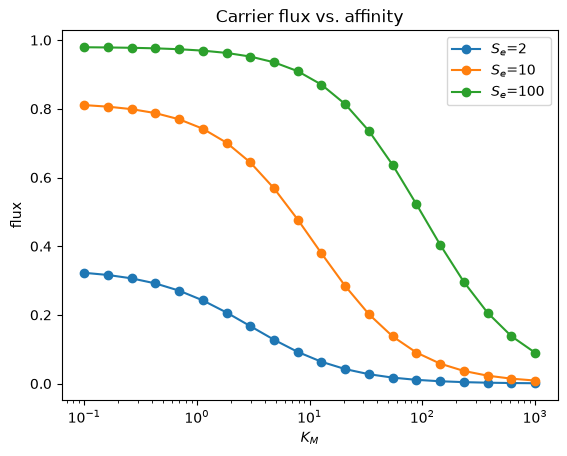

In [12]:
fig, ax = plt.subplots()
for se, g in flux_data.groupby('Se'):
    ax.plot(g['Km'], g['flux'], 'o-', label=f'$S_e$={se}')

ax.set_xscale('log')
ax.set_xlabel('$K_M$')
ax.set_ylabel('flux')
ax.set_title('Carrier flux vs. affinity')
ax.legend()

### Effect of the internal concentration $S_i$
So far, we only tested the effect of the external concentration $S_e$ on the fluxes. However, the flux also depends on the internal concentration of $S_i$. If $S_i$ is much smaller than the Km, there is almost no efflux and the optimal Km shifts to lower and lower values.

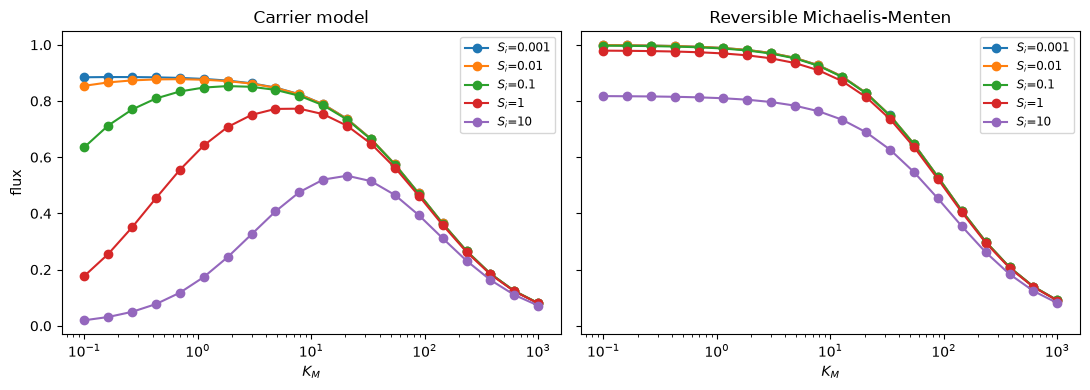

In [13]:
si_values = np.logspace(-3, 1, 5)

rows = []
for si in si_values:
    set_species('Si', initial_concentration=si)
    for km in km_values:
        set_parameters('Km', initial_value=km)
        run_steadystate()
        fluxes = get_reactions()['flux']
        rows.append({'Si': si, 'Km': km, 'carrier': fluxes['R1'], 'MM': fluxes['R2']})

set_parameters('Km', initial_value=Km)  # restore original value
set_species('Si', initial_concentration=0)  # restore original value
si_data = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for si, g in si_data.groupby('Si'):
    axes[0].plot(g['Km'], g['carrier'], 'o-', label=f'$S_i$={si:.3g}')
    axes[1].plot(g['Km'], g['MM'], 'o-', label=f'$S_i$={si:.3g}')

for ax, title in zip(axes, ['Carrier model', 'Reversible Michaelis-Menten']):
    ax.set_xscale('log')
    ax.set_xlabel('$K_M$')
    ax.set_title(title)
    ax.legend(fontsize='small')
axes[0].set_ylabel('flux')
fig.tight_layout()

Both models' fluxes fall as $S_i$ rises (less net driving force, $S_e - S_i$ or its analogue) &mdash; but the carrier model's curves also *shift and reshape* more strongly through the $\alpha S_e S_i/K_M^2$ term, which the MM model doesn't have. This coupling to the internal concentration, not the absolute size of $S_i$ alone, is the real distinguishing feature of carrier kinetics.

## A realistic glycolysis model
So far we've used a toy carrier in isolation, with $S_i$ set by hand. In a real cell, the "internal concentration" is itself a variable, set by the balance between import and downstream consumption. What's a realistic value, and can we predict it?

We'll explore this with a published kinetic model of yeast glycolysis: **vanHeerden1**, from the [JWS Online](https://jjj.bio.vu.nl/) model database, based on [van Heerden et al. (2014), *Science* 343:1245114](https://dx.doi.org/10.1126/science.1245114). It has 24 species and 18 reactions.

Two species are relevant to us:
- **GLCo** (extracellular glucose): `fixed` &mdash; an external condition we control, just like $S_e$ above.
- **GLCi** (intracellular glucose): a normal, `reactions`-determined species &mdash; its steady-state concentration is *predicted* by the model, which is exactly what we want to explore.

The glucose transporter is reaction **v14** (`GLCo -> GLCi`), using the same carrier-type rate law as our toy model above (with a fixed $\alpha=0.91$ built into this particular model). The first enzymatic step of glycolysis proper, hexokinase, is reaction **v1** (`GLCi -> G6P`).

### Loading the model and checking its steady state
First, load the SBML file and confirm what steady-state intracellular glucose concentration the model actually predicts &mdash; **don't just trust the `initialConcentration` written in the file**, since that's typically just a starting guess for the ODE solver, not necessarily a converged steady state.

Text(0, 0.5, 'Concentration of intracellular glucose GLCi ')

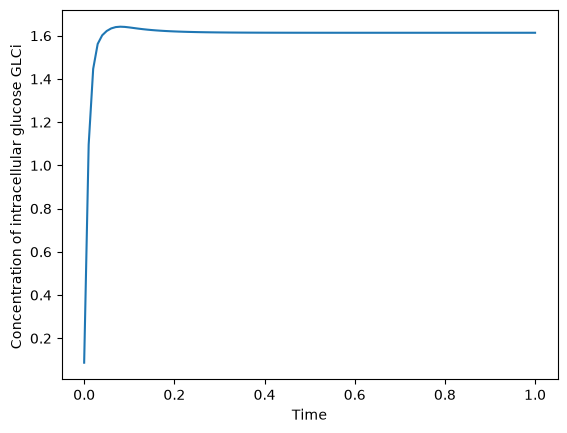

In [14]:
dm = load_model('vanHeerden1.xml')

result = run_time_course(duration=1, method='deterministic')

fig, ax = plt.subplots()
ax.plot(result.index, result.GLCi)
ax.set_xlabel('Time')
ax.set_ylabel('Concentration of intracellular glucose GLCi ')

In [15]:
status = run_steadystate()
print('GLCi steady-state concentration:', get_species().loc['GLCi', 'concentration'])

GLCi steady-state concentration: 1.615186143232424


### Scanning the transporter's affinity

The model has **two separate** $K_M$ parameters for the transporter, `KmGLTGLCi` and `KmGLTGLCo` (one per side, as in our toy carrier's single shared $K_M$, but here defined independently). To vary "the" transporter affinity as a single parameter, we map both reaction-level parameters to the same shared global value, so changing one changes both together.

In [16]:
set_reaction_parameters('(v14).KmGLTGLCi', mapped_to='KmGLTGLCo')
set_reaction_parameters('(v14).KmGLTGLCo', mapped_to='KmGLTGLCo')

get_reaction_parameters().loc[get_reaction_parameters()['reaction'] == 'v14']

,value,reaction,type,mapped_to
name,,,,
(v14).KeqGLT,1.0000,v14,global,KeqGLT
(v14).KmGLTGLCi,1.1918,v14,global,KmGLTGLCo
(v14).KmGLTGLCo,1.1918,v14,global,KmGLTGLCo
(v14).VmGLT,198.0000,v14,global,VmGLT


Now we reproduce the same style of analysis as for the toy carrier: scan the (shared) $K_M$ across several orders of magnitude, at two external glucose levels used in the original publication ($GLC_o = 5$ and $110$), and record the flux through the first glycolytic step (hexokinase, `v1`) and the resulting steady-state intracellular glucose concentration.

Some $(K_M, GLC_o)$ combinations may fail to converge to a steady state at all (the model is much more nonlinear than our toy carrier) &mdash; we skip those points rather than letting the loop crash.

In [17]:
glco_values = [5, 110]
km_values = np.logspace(-2, 3, 20)

rows = []
for glco in glco_values:
    set_species('GLCo', initial_concentration=glco)
    for km in km_values:
        set_parameters('KmGLTGLCo', initial_value=km)
        status = run_steadystate()
        if status != 1:
            continue  # steady state not found for this combination; skip it
        rows.append({
            'GLCo': glco,
            'Km': km,
            'flux_hexokinase': get_reactions().loc['v1', 'flux'],
            'GLCi': get_species().loc['GLCi', 'concentration'],
        })

glyco_data = pd.DataFrame(rows)
glyco_data.head()

Error while running the simulation: >WARNING 2026-08-18T13:42:32<
  CSteadyState (2): No steady state was found.


,GLCo,Km,flux_hexokinase,GLCi
0,5,0.010000,25.737019,0.072151
1,5,0.018330,31.861511,0.101994
2,5,0.033598,38.492952,0.146117
3,5,0.061585,45.385859,0.211389
4,5,0.112884,52.314112,0.306292


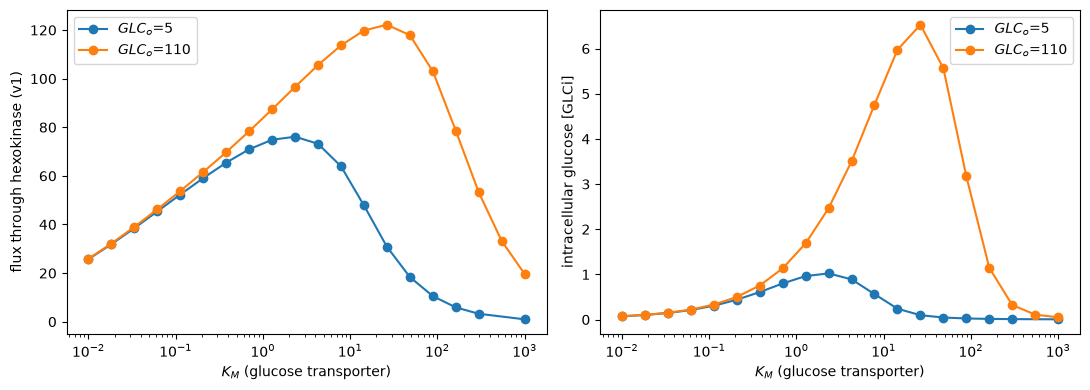

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for glco, g in glyco_data.groupby('GLCo'):
    axes[0].plot(g['Km'], g['flux_hexokinase'], 'o-', label=f'$GLC_o$={glco}')
    axes[1].plot(g['Km'], g['GLCi'], 'o-', label=f'$GLC_o$={glco}')

for ax, ylabel in zip(axes, ['flux through hexokinase (v1)', 'intracellular glucose [GLCi]']):
    ax.set_xscale('log')
    ax.set_xlabel('$K_M$ (glucose transporter)')
    ax.set_ylabel(ylabel)
    ax.legend()

fig.tight_layout()

Just like our toy model, the flux through glycolysis is **not** a monotonically increasing function of transporter affinity &mdash; it peaks at an intermediate $K_M$, and that optimum shifts to *higher* $K_M$ (lower affinity) as external glucose $GLC_o$ increases. Too high an affinity actually traps glucose transport in a regime where the trans-effect (via $\alpha$) reduces net uptake, exactly as we saw in the toy model.

## Conclusion

We reproduced, in both a minimal toy model and a realistic yeast glycolysis model, the result that:

- There is an **optimal transporter affinity** given fixed external and internal substrate concentrations.
- **Higher affinity does not always lead to higher flux** &mdash; a carrier that binds its substrate too tightly on one side can be throttled by the trans-effect on the other.
